<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 2
## Classical models and classification
**Logistic regression, SVM, tree, k-NN, Naive Bayes; evaluation; and seeing the data with PCA and t-SNE**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
> Semmelweis University · Luca Szegletes (BME)
---

In [1]:
# Install packages (Colab). Skip if already available locally.
!pip -q install ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
from ucimlrepo import fetch_ucirepo

## 0. Load and set up

In [3]:
heart = fetch_ucirepo(id=45)
X = heart.data.features.copy()
y = (heart.data.targets["num"] > 0).astype(int)   # binary target: disease vs no disease
numeric = ["age","trestbps","chol","thalach","oldpeak"]
categorical = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]
print("Shape:", X.shape, "| disease share:", round(y.mean(),3))

Shape: (303, 13) | disease share: 0.459


### Preprocessing and split

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 20% test, random_state=42, stratified split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# numeric -> impute median + scale
# categorical -> impute most_frequent + one-hot
pre = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric),

    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

## 1. Logistic regression in a pipeline
Wrap preprocessing and the model together, fit on the training data.

In [5]:
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(max_iter=1000))
])

# fit on the training data
clf.fit(X_tr, y_tr)

print("Test accuracy:", round(clf.score(X_te, y_te), 3))

Test accuracy: 0.885


## 2. The confusion matrix and clinical metrics
Accuracy is not enough. Read the confusion matrix, and compute sensitivity and specificity.

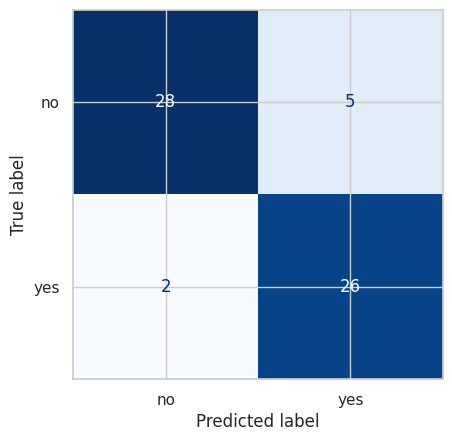

Sensitivity (recall): 0.929
Specificity: 0.848
              precision    recall  f1-score   support

  no disease       0.93      0.85      0.89        33
     disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = clf.predict(X_te)

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["no", "yes"]).plot(cmap="Blues", colorbar=False)
plt.show()

tn, fp, fn, tp = cm.ravel()

# TODO: sensitivity = tp/(tp+fn), specificity = tn/(tn+fp)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity (recall):", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print(classification_report(y_te, y_pred, target_names=["no disease", "disease"]))

## 3. ROC curve and AUC
Judge the model across all thresholds, not just at 0.5.

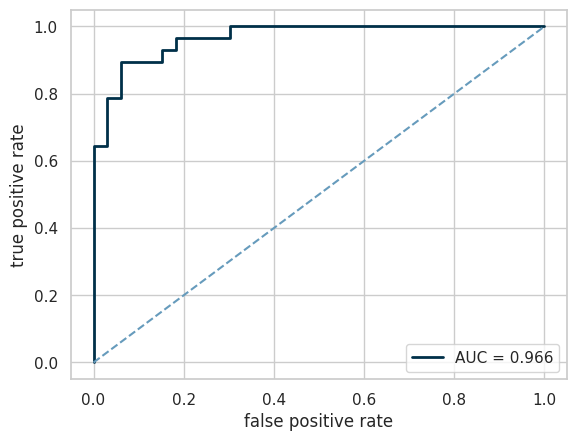

In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

proba = clf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, proba)

# TODO: compute the AUC for the label
auc = roc_auc_score(y_te, proba)

plt.plot(fpr, tpr, color="#003049", lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="#669bbc")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend()
plt.show()

## 4. Comparing five classifiers
Same data, same preprocessing, different boundary shapes. Compare cross-validated AUC.

In [8]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=0),
    "K-NN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
}

for name, m in models.items():
    pipe = Pipeline([
        ("pre", pre),
        ("model", m)
    ])

    # TODO: 5-fold cross-validated ROC AUC on the training data
    auc = cross_val_score(
        pipe,
        X_tr,
        y_tr,
        cv=5,
        scoring="roc_auc"
    ).mean()

    print(f"{name:15} CV-AUC: {auc:.3f}")

Logistic        CV-AUC: 0.894
SVM             CV-AUC: 0.877
Decision Tree   CV-AUC: 0.800
K-NN            CV-AUC: 0.867
Naive Bayes     CV-AUC: 0.876


## 5. Dimensionality reduction: PCA
Thirteen features are hard to picture. PCA compresses them to two directions of greatest variance.
It is for the eye only; the classifier still uses all features.

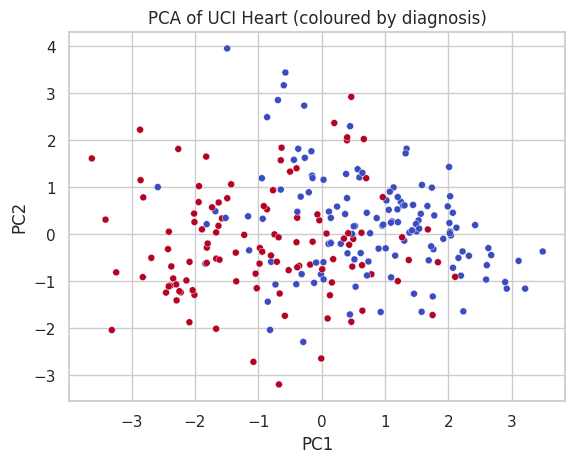

explained variance ratio: [0.253 0.142]


In [9]:
from sklearn.decomposition import PCA

Xt = pre.fit_transform(X_tr)
Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt

# TODO: PCA to 2 components, then fit_transform Xt
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xt)

plt.scatter(Z[:, 0], Z[:, 1], c=y_tr, cmap="coolwarm", s=25, edgecolor="white", linewidth=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of UCI Heart (coloured by diagnosis)")
plt.show()

print("explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

## 6. Dimensionality reduction: t-SNE
t-SNE keeps nearby patients nearby. Non-linear, slower, and good at revealing clusters.

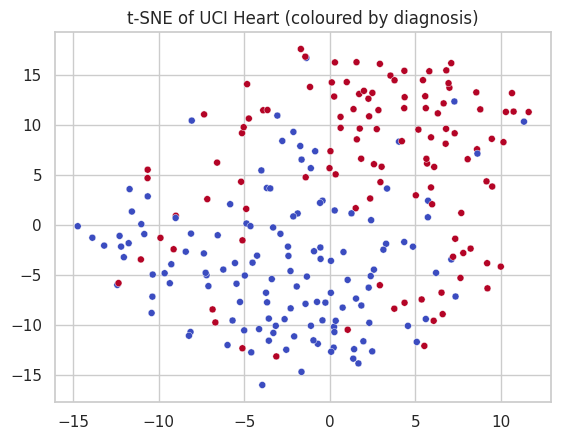

In [10]:
from sklearn.manifold import TSNE

# TODO: t-SNE to 2 components, perplexity=30, then fit_transform Xt
Z2 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0
).fit_transform(Xt)

plt.scatter(
    Z2[:, 0],
    Z2[:, 1],
    c=y_tr,
    cmap="coolwarm",
    s=25,
    edgecolor="white",
    linewidth=0.3
)

plt.title("t-SNE of UCI Heart (coloured by diagnosis)")
plt.show()

## Questions to think about
1. Which model won on cross-validated AUC? Was the difference large on this small dataset?
2. In PCA, how much variance do the first two components explain together? Is 2D enough to separate the classes?
3. Why is dimensionality reduction only for visualisation here, and not part of the classifier?

*Next session: regression - predicting a number (maximum heart rate) instead of a class.*